<a href="https://colab.research.google.com/github/peperjet/bc-ml/blob/main/real-estate-ml/apt2_260328.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [123]:
# 데이터 불러오기
import pandas as pd
import numpy as np

# 차트 및 폰트설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns


# 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams['font.family'] = font_name
mpl.rcParams['axes.unicode_minus'] = False

# train 이라는 객체에 'train.csv' 파일 할당해 줍니다
train = pd.read_csv('/content/train.csv')



In [124]:
#폰트설치

!apt-get update -qq
!apt-get install -y fonts-nanum
!fc-cache -fv

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 22 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped dire

In [125]:
# train 데이터 상위 5개행 출력
train.head()

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,2002,200801,21~31,2,37500
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,1973,200801,1~10,6,20000
2,2,3578,서울특별시,필운동,174-1,두레엘리시안,필운동 174-1 두레엘리시안,84.74,2007,200801,1~10,6,38500
3,3,10957,서울특별시,내수동,95,파크팰리스,내수동 95 파크팰리스,146.39,2003,200801,11~20,15,118000
4,4,10639,서울특별시,내수동,110-15,킹스매너,내수동 110-15 킹스매너,194.43,2004,200801,21~31,3,120000


In [126]:
# train 데이터 전체 정보 요약
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1216553 entries, 0 to 1216552
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   transaction_id          1216553 non-null  int64  
 1   apartment_id            1216553 non-null  int64  
 2   city                    1216553 non-null  object 
 3   dong                    1216553 non-null  object 
 4   jibun                   1216553 non-null  object 
 5   apt                     1216553 non-null  object 
 6   addr_kr                 1216553 non-null  object 
 7   exclusive_use_area      1216553 non-null  float64
 8   year_of_completion      1216553 non-null  int64  
 9   transaction_year_month  1216553 non-null  int64  
 10  transaction_date        1216553 non-null  object 
 11  floor                   1216553 non-null  int64  
 12  transaction_real_price  1216553 non-null  int64  
dtypes: float64(1), int64(6), object(6)
memory usage: 120.7+ M

In [127]:
# 각 컬럼별 결측값 개수 출력
train.isnull().sum()

,0
transaction_id,0
apartment_id,0
city,0
dong,0
jibun,0
apt,0
addr_kr,0
exclusive_use_area,0
year_of_completion,0
transaction_year_month,0


In [128]:
# 수치형 컬럼의 통계를 요약하여 출력
train.describe()

,transaction_id,apartment_id,exclusive_use_area,year_of_completion,transaction_year_month,floor,transaction_real_price
count,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06
mean,6.091530e+05,6.299685e+03,7.816549e+01,1.998297e+03,2.012984e+05,9.343291e+00,3.822769e+04
std,3.526198e+05,3.581169e+03,2.915113e+01,8.941347e+00,2.905732e+02,6.606500e+00,3.104898e+04
min,0.000000e+00,0.000000e+00,9.260000e+00,1.961000e+03,2.008010e+05,-4.000000e+00,1.000000e+02
25%,3.041380e+05,3.345000e+03,5.976000e+01,1.993000e+03,2.010100e+05,4.000000e+00,1.900000e+04
50%,6.082760e+05,5.964000e+03,8.241000e+01,1.999000e+03,2.013120e+05,8.000000e+00,3.090000e+04
75%,9.124140e+05,9.436000e+03,8.497000e+01,2.005000e+03,2.015110e+05,1.300000e+01,4.700000e+04
max,1.234827e+06,1.265800e+04,4.243200e+02,2.017000e+03,2.017110e+05,8.000000e+01,8.200000e+05


In [129]:
# 범주형 컬럼 통계 요약 출력
train.describe(include=['object'])

,city,dong,jibun,apt,addr_kr,transaction_date
count,1216553,1216553,1216553,1216553,1216553,1216553
unique,2,473,8961,10440,12533,6
top,서울특별시,상계동,176-30,현대,용호동 944 오륙도에스케이뷰,11~20
freq,742285,29346,6594,13154,3220,408385


add_kr 주소


In [130]:
train['city'].value_counts()

,count
city,
서울특별시,742285
부산광역시,474268


In [131]:
train['city']=='부산광역시'

,city
0,False
1,False
2,False
3,False
4,False
...,...
1216548,True
1216549,True
1216550,True
1216551,True


In [132]:
train[train['city']=='부산광역시']

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
650921,650921,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),57.0900,1998,200801,1~10,4,7900
650922,650922,2939,부산광역시,영주동,587,도경오벨리스,영주동 587 도경오벨리스,84.9700,2005,200801,1~10,12,13000
650923,650923,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.8600,1997,200801,11~20,7,12400
650924,650924,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),84.7200,1998,200801,11~20,14,10600
650925,650925,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.5900,1997,200801,21~31,5,10000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1216548,1234823,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,59.8245,2012,201711,11~20,3,22000
1216549,1234824,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,7,30750
1216550,1234825,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,9,29500
1216551,1234826,9586,부산광역시,정관읍 용수리,1364,정관신도시롯데캐슬,정관읍 용수리 1364 정관신도시롯데캐슬,101.7400,2008,201711,21~30,7,26700


In [133]:
train.loc[train['city']=='부산광역시',:]

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
650921,650921,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),57.0900,1998,200801,1~10,4,7900
650922,650922,2939,부산광역시,영주동,587,도경오벨리스,영주동 587 도경오벨리스,84.9700,2005,200801,1~10,12,13000
650923,650923,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.8600,1997,200801,11~20,7,12400
650924,650924,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),84.7200,1998,200801,11~20,14,10600
650925,650925,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.5900,1997,200801,21~31,5,10000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1216548,1234823,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,59.8245,2012,201711,11~20,3,22000
1216549,1234824,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,7,30750
1216550,1234825,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,9,29500
1216551,1234826,9586,부산광역시,정관읍 용수리,1364,정관신도시롯데캐슬,정관읍 용수리 1364 정관신도시롯데캐슬,101.7400,2008,201711,21~30,7,26700


In [134]:
train.loc[train['city']=='부산광역시',['year_of_completion','transaction_year_month']]

,year_of_completion,transaction_year_month
650921,1998,200801
650922,2005,200801
650923,1997,200801
650924,1998,200801
650925,1997,200801
...,...,...
1216548,2012,201711
1216549,2012,201711
1216550,2012,201711
1216551,2008,201711


In [135]:
train.iloc[:,[8,9]]

,year_of_completion,transaction_year_month
0,2002,200801
1,1973,200801
2,2007,200801
3,2003,200801
4,2004,200801
...,...,...
1216548,2012,201711
1216549,2012,201711
1216550,2012,201711
1216551,2008,201711


In [136]:
train.iloc[9:20,[8,9]]

,year_of_completion,transaction_year_month
9,2006,200801
10,2004,200801
11,2002,200801
12,2003,200801
13,1999,200801
14,1999,200801
15,1999,200801
16,1999,200801
17,1968,200801
18,1999,200801


2단계 EDA

In [137]:
import pip
!pip install seaborn

In [138]:
plt.style.use("fivethirtyeight")

In [139]:
train = pd.read_csv('train.csv')


In [140]:
train.head(2)

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,2002,200801,21~31,2,37500
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,1973,200801,1~10,6,20000


In [141]:
#transaction_year_month 연도와 월을 분리해 줍니다
train['year'] = train['transaction_year_month'].astype(str).str[:4].astype(int)
train['month'] = train['transaction_year_month'].astype(str).str[4:].astype(int)

In [142]:
train.head()

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price,year,month
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,2002,200801,21~31,2,37500,2008,1
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,1973,200801,1~10,6,20000,2008,1
2,2,3578,서울특별시,필운동,174-1,두레엘리시안,필운동 174-1 두레엘리시안,84.74,2007,200801,1~10,6,38500,2008,1
3,3,10957,서울특별시,내수동,95,파크팰리스,내수동 95 파크팰리스,146.39,2003,200801,11~20,15,118000,2008,1
4,4,10639,서울특별시,내수동,110-15,킹스매너,내수동 110-15 킹스매너,194.43,2004,200801,21~31,3,120000,2008,1


transaction_date

In [143]:
train['transaction_date'].value_counts()

,count
transaction_date,
11~20,408385
1~10,391715
21~31,250588
21~30,134017
21~28,22199
21~29,9649


In [144]:
# transaction_date에서 21~31, 21~30, 21~28, 21~29에 해당하는 값을 21~31로 변환

# 막대기 대신 리스트를 써서 깔끔하게 줄이는 방법
targets = ['21~30', '21~28', '21~29']
train.loc[train['transaction_date'].isin(targets), 'transaction_date'] = '21~31'


In [145]:
train['transaction_date'].value_counts()

,count
transaction_date,
21~31,416453
11~20,408385
1~10,391715


plt.figure  가로크기 세로크기
plt.그래프 종류() or sns.그래프 종류()
사용하고 싶은 그래프 종류에 따라 맞춰서 종류를 사용해야하고, 패키지에 있는 그래프 종류를 사용하면됩니다


In [146]:
# pie chart

seoul_busan = train['city'].value_counts()
seoul_busan

,count
city,
서울특별시,742285
부산광역시,474268


In [147]:

fonts = sorted(set(f.name for f in fm.fontManager.ttflist))
[x for x in fonts if 'Nanum' in x]

['NanumGothic']

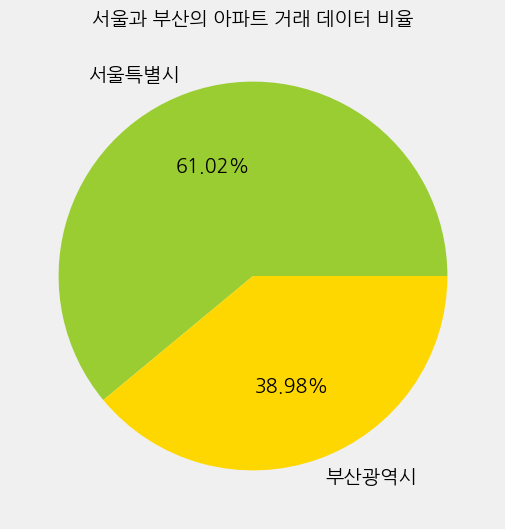

In [148]:
color = ['yellowgreen', 'gold']
iangs = ['서울특별시', '부산광역시']

plt.figure(figsize=(8,6))
plt.pie(
    seoul_busan,
    labels=iangs,
    colors=color,
    autopct='%.2f%%',
    textprops={'fontproperties': fontprop}
)
plt.title('서울과 부산의 아파트 거래 데이터 비율', fontsize=20, fontproperties=fontprop)
plt.show()

countplot

In [149]:
#연도별 count table
train['year'] = train['transaction_year_month'].astype(str).str[:4].astype(int)
train['month'] = train['transaction_year_month'].astype(str).str[4:].astype(int)
train_year_count = train['year'].value_counts().sort_index(ascending=True)
train_year_count

,count
year,
2008,100066
2009,127869
2010,102823
2011,98586
2012,70065
2013,109738
2014,136649
2015,181195
2016,165664


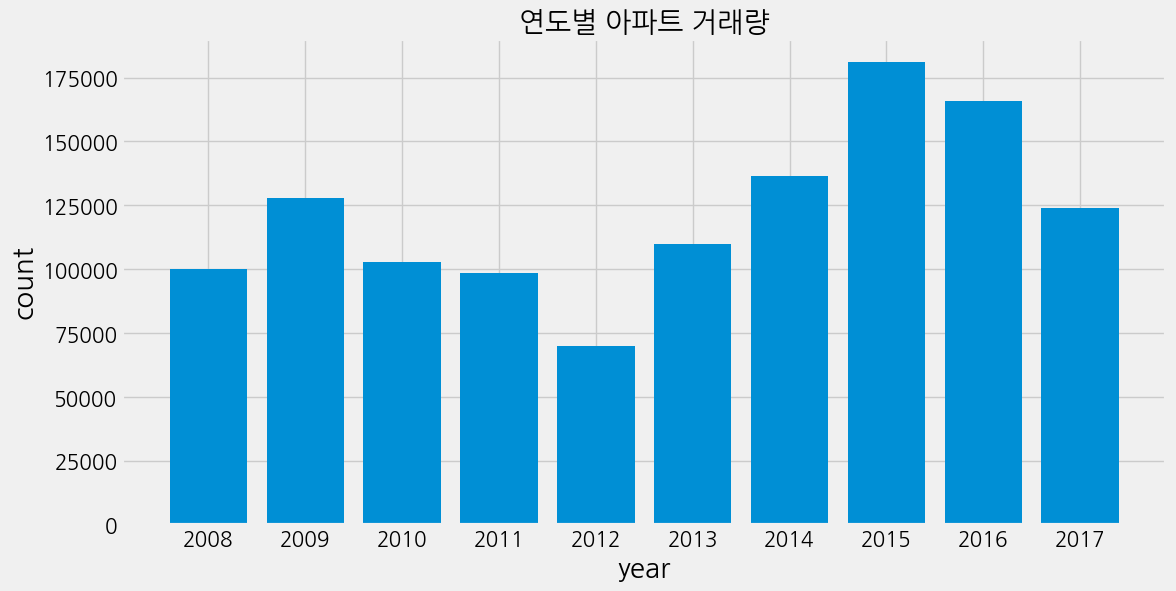

In [153]:
# matplotlib을 이용해 연도별 아파트 거래량 표기

plt.figure(figsize=(12,6))
plt.bar(train_year_count.index.astype(str), train_year_count.values)

plt.title('연도별 아파트 거래량', size=20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('year', size=20)
plt.ylabel('count', size=20)

plt.show()

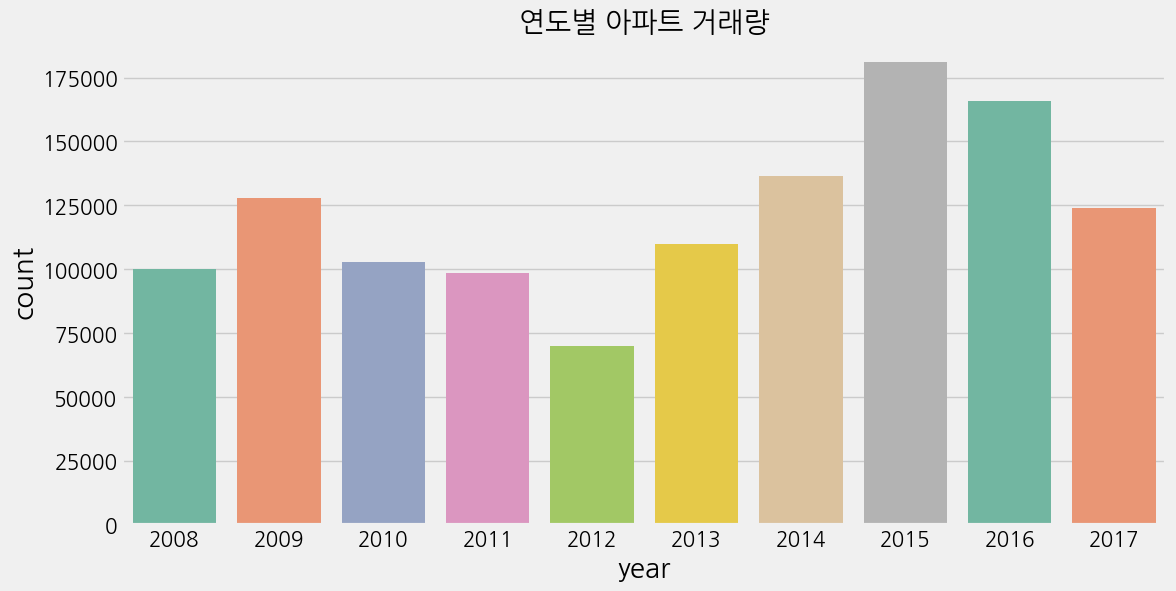

In [155]:
# seaborn의 countplot을 아용해 아파트 연도별 거래량

plt.figure(figsize=(12,6))
sns.countplot(x='year', data=train,  palette='Set2')
plt.title('연도별 아파트 거래량', size=20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('year', size=20)
plt.ylabel('count', size=20)

plt.show()

palette='Set2'      # 부드럽고 예쁨 (추천)
palette='Set3'      # 더 컬러풀
palette='tab10'     # 선명한 색
palette='pastel'    # 연한 색
palette='coolwarm'  # 그라데이션 느낌


seaborn은 기본이 단색이라 palette 넣어야 화려해진다

In [156]:
# 월별 count table

train_month_count = train['month'].value_counts().sort_index(ascending=True)
train_month_count

,count
month,
1,85622
2,95199
3,125958
4,115363
5,110536
6,109841
7,102973
8,96163
9,104061


In [158]:
# 월별 count table

train_month_count = train['transaction_date'].value_counts().sort_index(ascending=True).to_frame()
train_month_count

,count
transaction_date,
11~20,408385
1~10,391715
21~31,416453


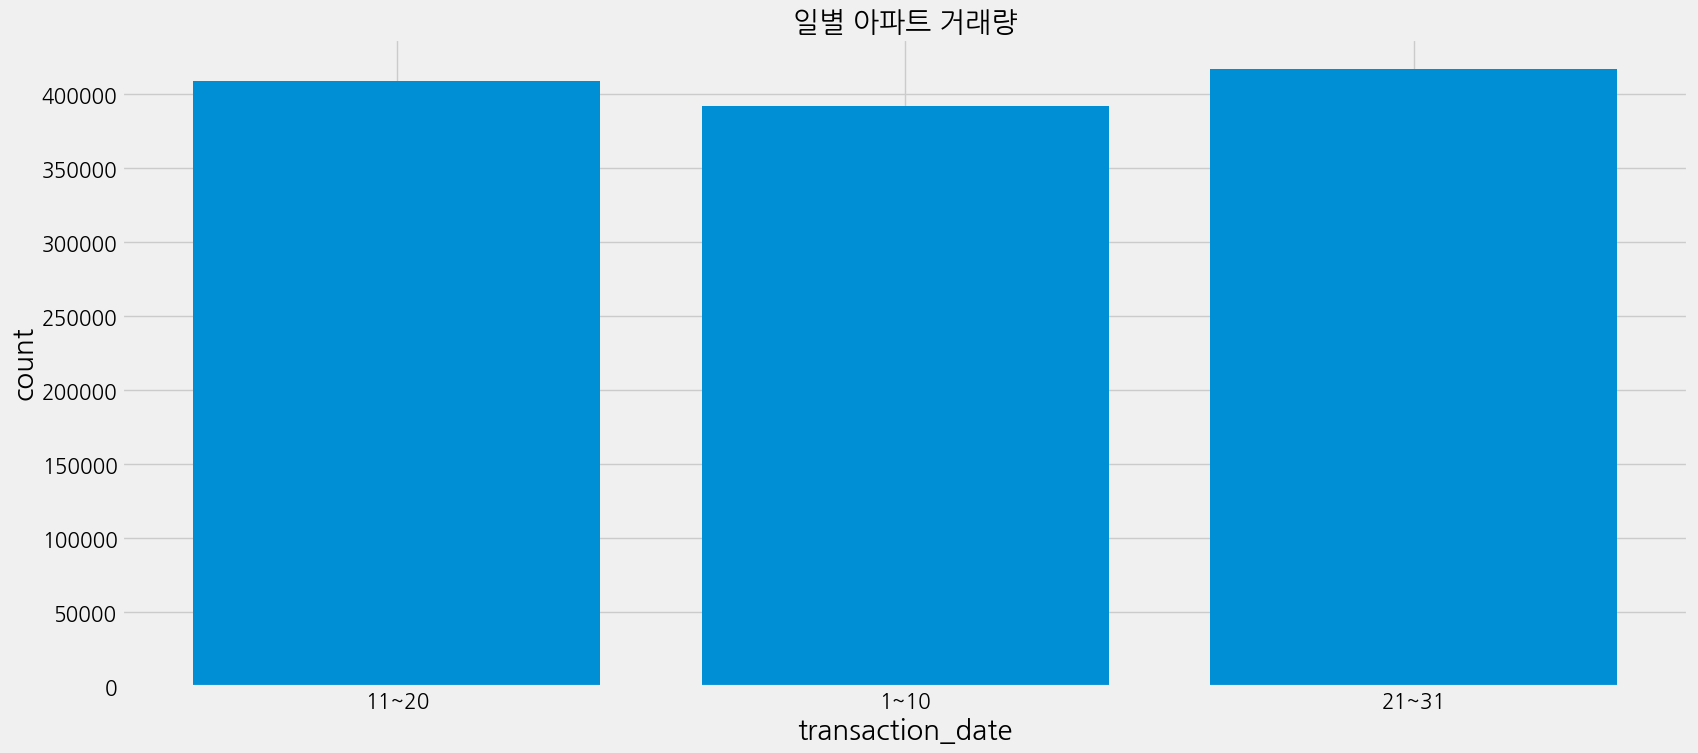

In [165]:
# matplotlib 이용해 일별 아파트 거래량

plt.figure(figsize=(18,8))
plt.bar(train_month_count.index.astype(str), train_month_count['count'])
plt.title('일별 아파트 거래량', size = 20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('transaction_date', size=20)
plt.ylabel('count', size=20)

plt.show()

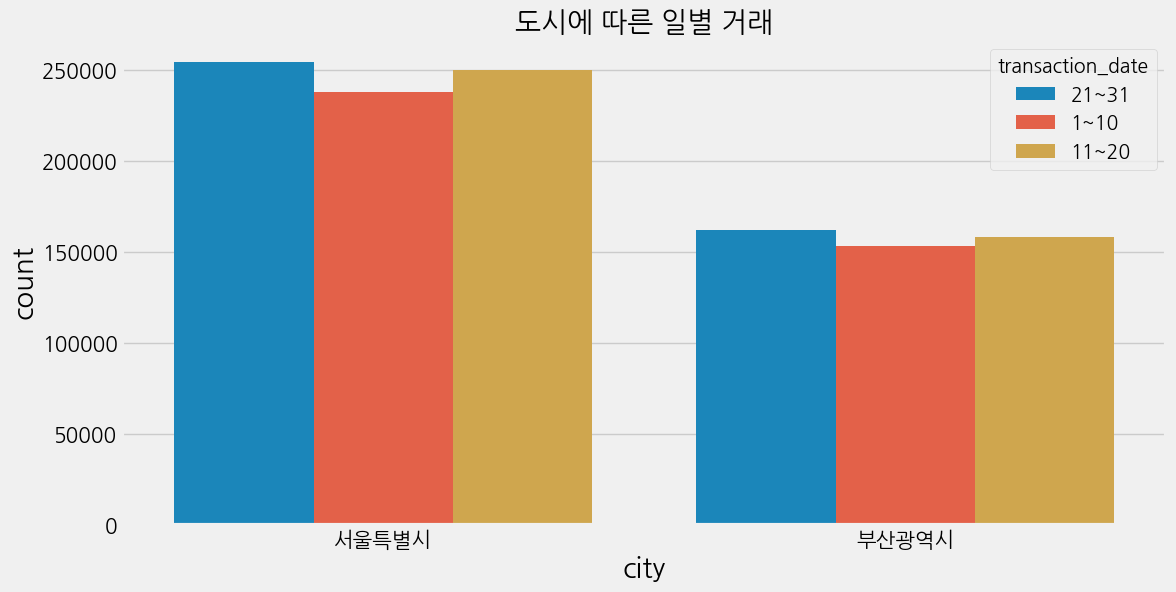

In [166]:
# 이변량 countplot

# seaborn의 countplot 도시에 따른 일별 거래

plt.figure(figsize=(12,6))
sns.countplot( x ='city', hue = 'transaction_date', data=train)
plt.title('도시에 따른 일별 거래', size=20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('city', size=20)
plt.ylabel('count', size=20)

plt.show()

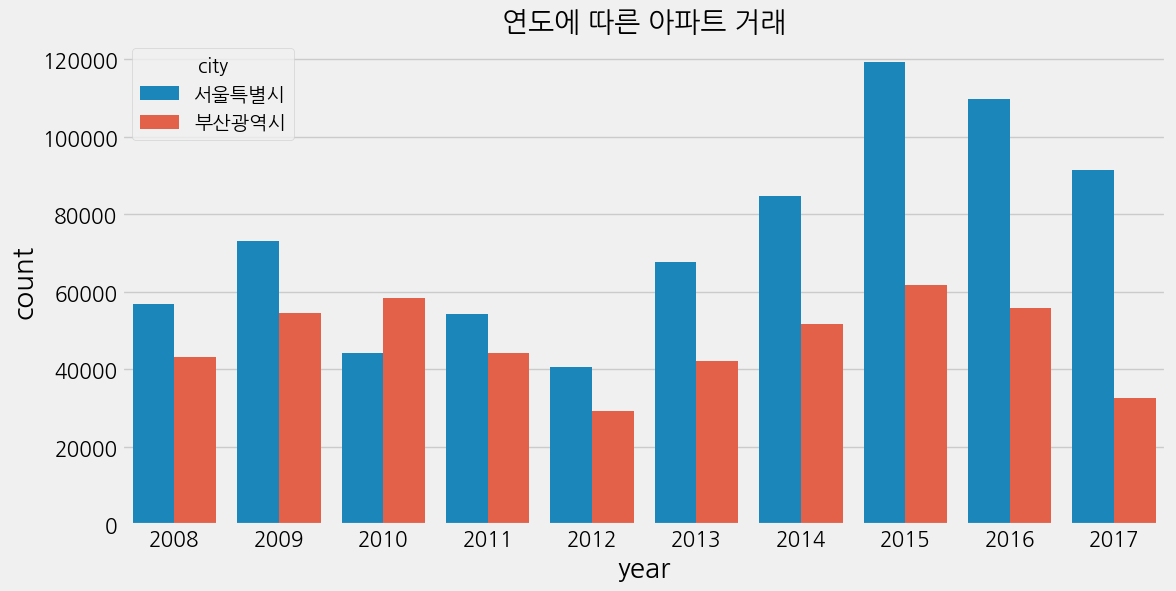

In [167]:
# seaborn의 countplot 연도에 따른 아파트 거래

plt.figure(figsize=(12,6))
sns.countplot(x = 'year', hue='city', data=train)
plt.title('연도에 따른 아파트 거래', size=20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('year', size=20)
plt.ylabel('count', size=20)

plt.show()